ABC-XYZ АНАЛИЗ АССОРТИМЕНТА
ШВЕЙНОЕ ПРОИЗВОДСТВО

📂 Загрузка данных...
✅ Транзакций: 101,089
✅ Товаров: 5,000
✅ Складов: 6

📊 Агрегация данных по товарам...
✅ Агрегировано 5000 товаров

📈 ABC-анализ...

📊 ABC-распределение:
   • Категория A: 2765.0 товаров (55.3%), выручка: 622.5M руб. (80.0%)
   • Категория B: 1191.0 товаров (23.8%), выручка: 116.8M руб. (15.0%)
   • Категория C: 1044.0 товаров (20.9%), выручка: 38.9M руб. (5.0%)

📊 XYZ-анализ...

📊 XYZ-распределение:
   • Категория X: 2 товаров (0.0%)
   • Категория Y: 840 товаров (16.8%)
   • Категория Z: 4158 товаров (83.2%)

📊 Матрица ABC-XYZ:

          X       Y       Z
A:        1     527    2237
B:        1     179    1011
C:        0     134     910

🎨 Создание визуализаций...


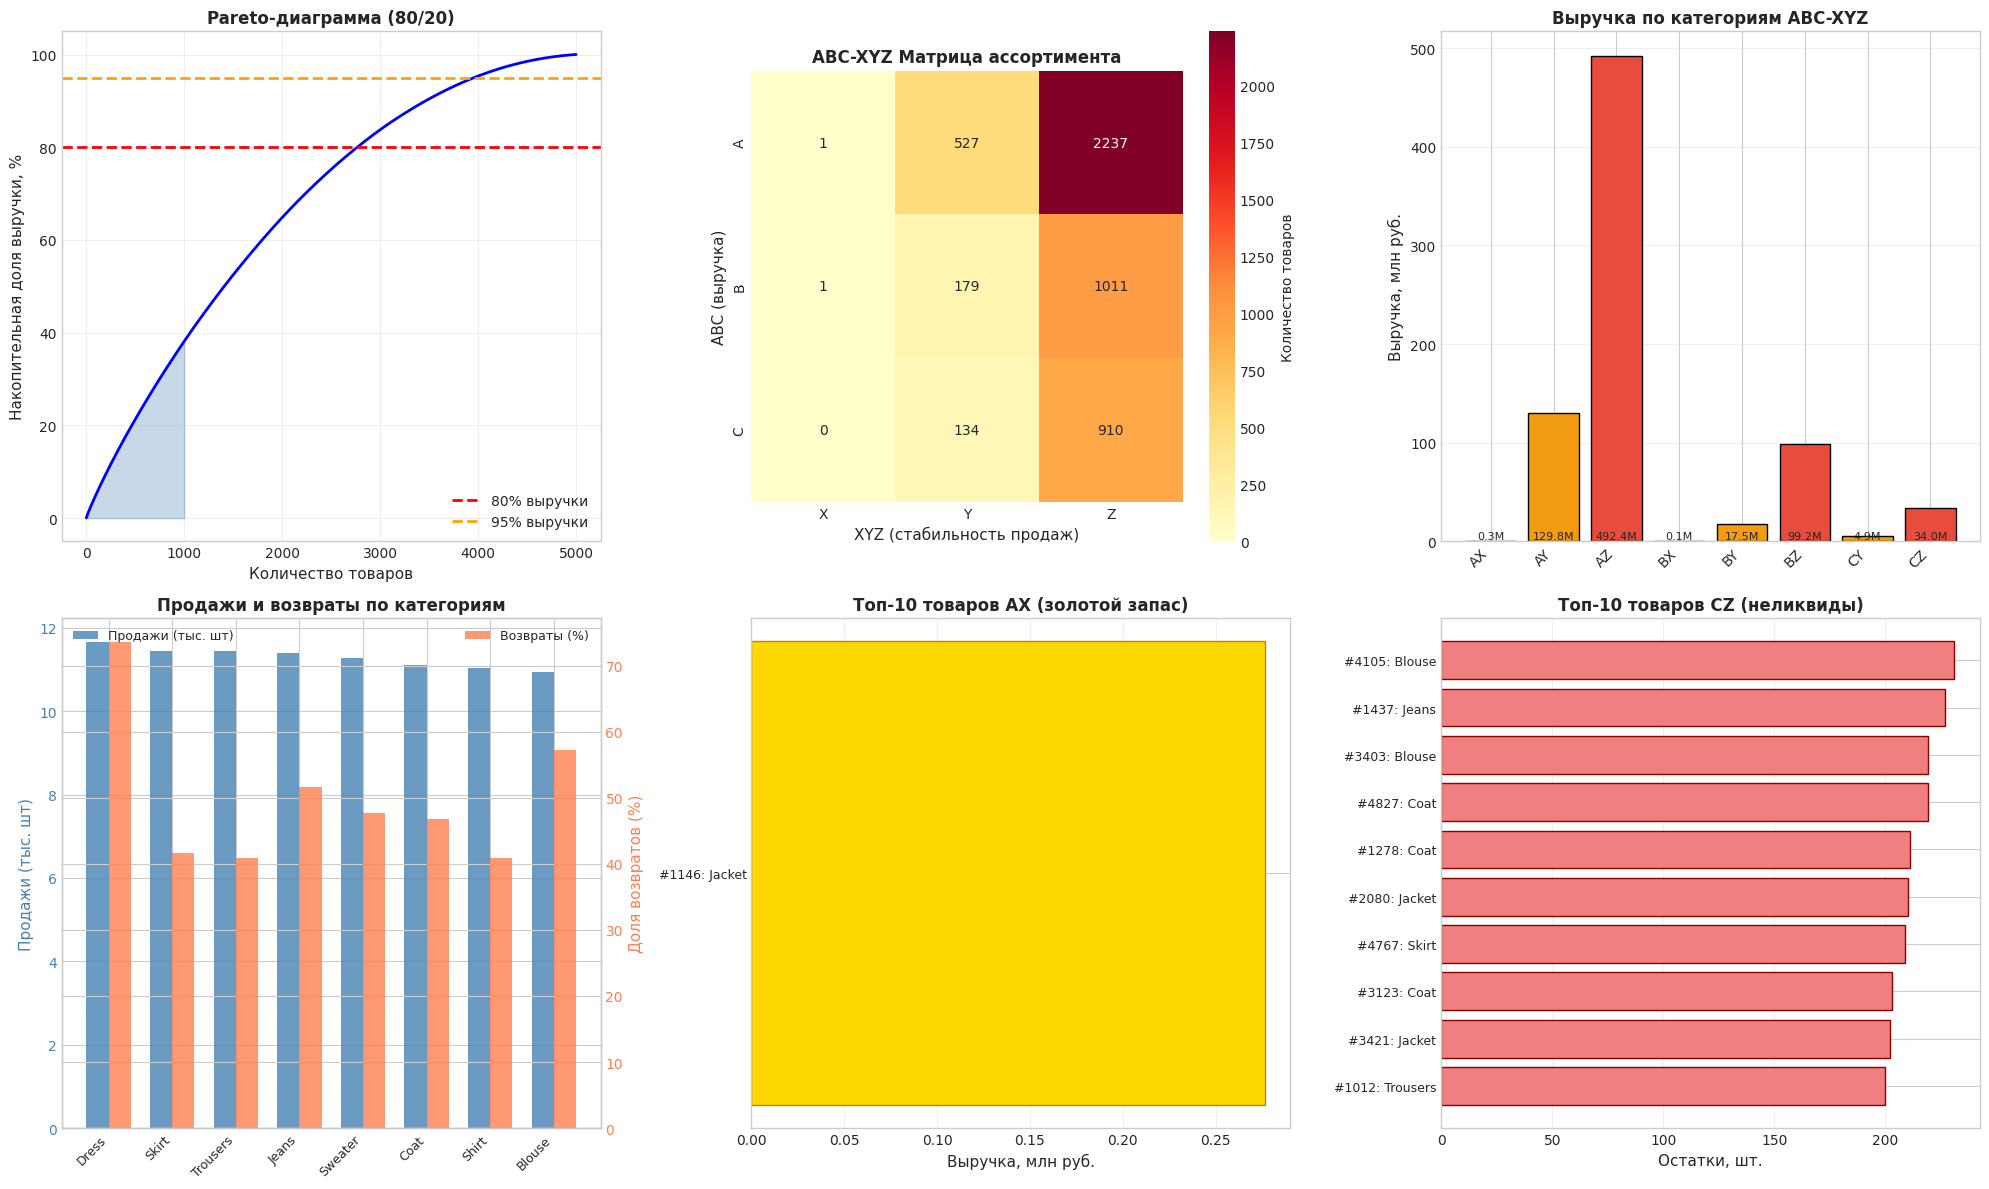

✅ Визуализация сохранена: abc_xyz_analysis_colab.png

💾 Сохранение результатов...
   ✅ abc_xyz_full_list.csv
   ✅ ax_golden_products.csv (1 товаров)
   ✅ cz_non_movers.csv (910 товаров)
   ✅ high_return_products.csv (4932 товаров)

СТРАТЕГИИ УПРАВЛЕНИЯ ПО КАТЕГОРИЯМ

📋 РЕКОМЕНДАЦИИ:

   AX (1 товаров):
   ✅ ЗОЛОТОЙ ЗАПАС: Высокая выручка, стабильный спрос. Стратегия: поддерживать запас, автоматическое пополнение.

   AY (527 товаров):
   📈 РАСТУЩИЕ ЗВЕЗДЫ: Высокая выручка, средняя стабильность. Стратегия: увеличить запас, отслеживать тренды.

   AZ (2237 товаров):
   🎲 ВОЛАТИЛЬНЫЕ ЛИДЕРЫ: Высокая выручка, нестабильный спрос. Стратегия: ситуативное управление, прогнозирование.

   BX (1 товаров):
   📦 СТАБИЛЬНЫЙ СЕРЕДНЯК: Средняя выручка, стабильный спрос. Стратегия: оптимизировать запас.

   BY (179 товаров):
   📊 ПЕРЕМЕННЫЙ СЕРЕДНЯК: Средняя выручка, колеблющийся спрос. Стратегия: анализ причин колебаний.

   BZ (1011 товаров):
   🌊 НЕСТАБИЛЬНЫЙ СЕРЕДНЯК: Средняя выручка, непредсказуе

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Настройка стиля
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['font.family'] = 'DejaVu Sans'

print("=" * 80)
print("ABC-XYZ АНАЛИЗ АССОРТИМЕНТА")
print("ШВЕЙНОЕ ПРОИЗВОДСТВО")
print("=" * 80)

# ============================================
# 1. ЗАГРУЗКА ДАННЫХ
# ============================================
print("\n📂 Загрузка данных...")

# Загружаем файлы 
articles = pd.read_csv('articles.csv', sep=';', encoding='utf-8', decimal=',')
transactions = pd.read_csv('transactions.csv', sep=';', encoding='utf-8', decimal=',')
stock = pd.read_csv('stock.csv', sep=';', encoding='utf-8', decimal=',')

# Конвертация дат
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])
transactions['month'] = transactions['t_dat'].dt.to_period('M')

print(f"✅ Транзакций: {len(transactions):,}")
print(f"✅ Товаров: {len(articles):,}")
print(f"✅ Складов: {stock['warehouse'].nunique()}")

# ============================================
# 2. АГРЕГАЦИЯ ПРОДАЖ ПО ТОВАРАМ
# ============================================
print("\n📊 Агрегация данных по товарам...")

product_sales = transactions.groupby('article_id').agg({
    'price': 'sum',
    'margin': 'sum',
    't_dat': 'count',
    'is_returned': 'mean'
}).rename(columns={
    'price': 'revenue',
    'margin': 'total_margin',
    't_dat': 'sales_count',
    'is_returned': 'return_rate'
})

# Добавляем информацию о товаре
product_sales = product_sales.merge(
    articles[['article_id', 'product_type_name', 'colour_group_name', 'size', 'price', 'cost']],
    on='article_id',
    how='left'
)

# Добавляем информацию об остатках (суммируем по всем складам)
stock_summary = stock.groupby('article_id').agg({
    'current_stock': 'sum',
    'stock_value': 'sum'
}).reset_index()

product_sales = product_sales.merge(stock_summary, on='article_id', how='left')
product_sales['current_stock'] = product_sales['current_stock'].fillna(0)
product_sales['stock_value'] = product_sales['stock_value'].fillna(0)

# Рассчитываем дополнительные метрики
product_sales['return_rate_pct'] = product_sales['return_rate'] * 100
product_sales['margin_pct'] = (product_sales['total_margin'] / product_sales['revenue'] * 100).fillna(0)
product_sales['turnover'] = product_sales['sales_count'] / (product_sales['current_stock'] + 1)  # +1 чтобы избежать деления на 0

print(f"✅ Агрегировано {len(product_sales)} товаров")

# ============================================
# 3. ABC-АНАЛИЗ (по выручке)
# ============================================
print("\n📈 ABC-анализ...")

product_sales = product_sales.sort_values('revenue', ascending=False).reset_index(drop=True)
product_sales['revenue_cumsum'] = product_sales['revenue'].cumsum()
total_revenue = product_sales['revenue'].sum()
product_sales['revenue_cumsum_pct'] = product_sales['revenue_cumsum'] / total_revenue * 100

def abc_classify(pct):
    if pct <= 80:
        return 'A'
    elif pct <= 95:
        return 'B'
    else:
        return 'C'

product_sales['abc'] = product_sales['revenue_cumsum_pct'].apply(abc_classify)

abc_stats = product_sales.groupby('abc').agg({
    'article_id': 'count',
    'revenue': 'sum'
}).rename(columns={'article_id': 'count'})
abc_stats['revenue_pct'] = abc_stats['revenue'] / total_revenue * 100

print("\n📊 ABC-распределение:")
for cat in ['A', 'B', 'C']:
    if cat in abc_stats.index:
        row = abc_stats.loc[cat]
        print(f"   • Категория {cat}: {row['count']} товаров ({row['count']/len(product_sales)*100:.1f}%), "
              f"выручка: {row['revenue']/1_000_000:.1f}M руб. ({row['revenue_pct']:.1f}%)")

# ============================================
# 4. XYZ-АНАЛИЗ (по стабильности продаж)
# ============================================
print("\n📊 XYZ-анализ...")

# Создаем матрицу продаж по месяцам
monthly_sales = transactions.groupby(['article_id', 'month']).size().unstack(fill_value=0)

def coefficient_of_variation(sales_series):
    if len(sales_series) == 0 or sales_series.sum() == 0:
        return 100
    mean = sales_series.mean()
    std = sales_series.std()
    if mean == 0:
        return 100
    return (std / mean) * 100

# Рассчитываем CV для каждого товара
cv_dict = {}
for article_id in product_sales['article_id']:
    if article_id in monthly_sales.index:
        sales = monthly_sales.loc[article_id]
        cv = coefficient_of_variation(sales)
    else:
        cv = 100
    cv_dict[article_id] = cv

product_sales['cv'] = product_sales['article_id'].map(cv_dict)

def classify_xyz(cv):
    if cv <= 30:
        return 'X'
    elif cv <= 60:
        return 'Y'
    else:
        return 'Z'

product_sales['xyz'] = product_sales['cv'].apply(classify_xyz)
product_sales['abc_xyz'] = product_sales['abc'] + product_sales['xyz']

xyz_stats = product_sales.groupby('xyz').size()
print("\n📊 XYZ-распределение:")
for cat in ['X', 'Y', 'Z']:
    if cat in xyz_stats.index:
        count = xyz_stats[cat]
        print(f"   • Категория {cat}: {count} товаров ({count/len(product_sales)*100:.1f}%)")

# ============================================
# 5. МАТРИЦА ABC-XYZ
# ============================================
print("\n📊 Матрица ABC-XYZ:")

matrix = pd.crosstab(product_sales['abc'], product_sales['xyz'])
# Добавляем недостающие категории
for abc in ['A', 'B', 'C']:
    if abc not in matrix.index:
        matrix.loc[abc] = 0
for xyz in ['X', 'Y', 'Z']:
    if xyz not in matrix.columns:
        matrix[xyz] = 0
matrix = matrix.reindex(['A', 'B', 'C'])[['X', 'Y', 'Z']]

print("\n   " + "".join([f"{col:>8s}" for col in matrix.columns]))
for idx in matrix.index:
    row_str = f"{idx}: " + "".join([f"{matrix.loc[idx, col]:>8d}" for col in matrix.columns])
    print(row_str)

# ============================================
# 6. ВИЗУАЛИЗАЦИЯ
# ============================================
print("\n🎨 Создание визуализаций...")

fig = plt.figure(figsize=(20, 12))

# 6.1 Pareto-диаграмма
ax1 = plt.subplot(2, 3, 1)
x = range(1, len(product_sales) + 1)
y = product_sales['revenue_cumsum_pct'].values
ax1.plot(x, y, 'b-', linewidth=2)
ax1.axhline(y=80, color='r', linestyle='--', label='80% выручки', linewidth=2)
ax1.axhline(y=95, color='orange', linestyle='--', label='95% выручки', linewidth=2)
ax1.fill_between(x[:int(len(x)*0.2)], y[:int(len(x)*0.2)], alpha=0.3, color='steelblue')
ax1.set_xlabel('Количество товаров', fontsize=11)
ax1.set_ylabel('Накопительная доля выручки, %', fontsize=11)
ax1.set_title('Pareto-диаграмма (80/20)', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 6.2 Тепловая карта ABC-XYZ
ax2 = plt.subplot(2, 3, 2)
sns.heatmap(matrix, annot=True, fmt='d', cmap='YlOrRd', ax=ax2,
            cbar_kws={'label': 'Количество товаров'}, square=True)
ax2.set_title('ABC-XYZ Матрица ассортимента', fontsize=12, fontweight='bold')
ax2.set_xlabel('XYZ (стабильность продаж)', fontsize=11)
ax2.set_ylabel('ABC (выручка)', fontsize=11)

# 6.3 Выручка по категориям ABC-XYZ
ax3 = plt.subplot(2, 3, 3)
revenue_by_cat = product_sales.groupby('abc_xyz')['revenue'].sum()
# Сортируем в правильном порядке
cat_order = ['AX', 'AY', 'AZ', 'BX', 'BY', 'BZ', 'CX', 'CY', 'CZ']
revenue_by_cat = revenue_by_cat.reindex([c for c in cat_order if c in revenue_by_cat.index])
colors = ['#2ecc71' if 'X' in cat else '#f39c12' if 'Y' in cat else '#e74c3c'
          for cat in revenue_by_cat.index]
bars = ax3.bar(range(len(revenue_by_cat)), revenue_by_cat.values/1_000_000,
               color=colors, edgecolor='black', linewidth=1)
ax3.set_xticks(range(len(revenue_by_cat)))
ax3.set_xticklabels(revenue_by_cat.index, rotation=45, ha='right')
ax3.set_ylabel('Выручка, млн руб.', fontsize=11)
ax3.set_title('Выручка по категориям ABC-XYZ', fontsize=12, fontweight='bold')
for bar, val in zip(bars, revenue_by_cat.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height()/1_000_000 + 0.5,
             f'{val/1_000_000:.1f}M', ha='center', va='bottom', fontsize=8)
ax3.grid(True, alpha=0.3, axis='y')

# 6.4 Продажи и возвраты по категориям товаров
ax4 = plt.subplot(2, 3, 4)
category_stats = transactions.groupby('product_type_name').agg({
    'article_id': 'count',
    'is_returned': 'mean',
    'price': 'mean'
}).rename(columns={'article_id': 'sales', 'is_returned': 'return_rate', 'price': 'avg_price'})
category_stats['return_rate'] = category_stats['return_rate'] * 100
category_stats = category_stats.sort_values('sales', ascending=False).head(8)

x_pos = range(len(category_stats))
width = 0.35
bars1 = ax4.bar([i - width/2 for i in x_pos], category_stats['sales']/1000,
                width, label='Продажи (тыс. шт)', color='steelblue', alpha=0.8)
ax4.set_ylabel('Продажи (тыс. шт)', color='steelblue', fontsize=11)
ax4.tick_params(axis='y', labelcolor='steelblue')
ax4_twin = ax4.twinx()
bars2 = ax4_twin.bar([i + width/2 for i in x_pos], category_stats['return_rate'],
                      width, label='Возвраты (%)', color='coral', alpha=0.8)
ax4_twin.set_ylabel('Доля возвратов (%)', color='coral', fontsize=11)
ax4_twin.tick_params(axis='y', labelcolor='coral')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(category_stats.index, rotation=45, ha='right', fontsize=9)
ax4.set_title('Продажи и возвраты по категориям', fontsize=12, fontweight='bold')
ax4.legend(loc='upper left', fontsize=9)
ax4_twin.legend(loc='upper right', fontsize=9)

# 6.5 Топ-10 товаров AX (золотой запас)
ax5 = plt.subplot(2, 3, 5)
ax_products = product_sales[product_sales['abc_xyz'] == 'AX'].nlargest(10, 'revenue')
bars = ax5.barh(range(len(ax_products)), ax_products['revenue']/1_000_000,
                color='gold', edgecolor='darkgoldenrod', linewidth=1)
ax5.set_yticks(range(len(ax_products)))
labels = [f"#{row['article_id']}: {row['product_type_name'][:15]}" for _, row in ax_products.iterrows()]
ax5.set_yticklabels(labels, fontsize=9)
ax5.set_xlabel('Выручка, млн руб.', fontsize=11)
ax5.set_title('Топ-10 товаров AX (золотой запас)', fontsize=12, fontweight='bold')
ax5.invert_yaxis()
ax5.grid(True, alpha=0.3, axis='x')

# 6.6 Топ-10 товаров CZ (неликвиды)
ax6 = plt.subplot(2, 3, 6)
cz_products = product_sales[product_sales['abc_xyz'] == 'CZ'].nlargest(10, 'current_stock')
if len(cz_products) > 0:
    bars = ax6.barh(range(len(cz_products)), cz_products['current_stock'],
                    color='lightcoral', edgecolor='darkred', linewidth=1)
    ax6.set_yticks(range(len(cz_products)))
    labels = [f"#{row['article_id']}: {row['product_type_name'][:15]}" for _, row in cz_products.iterrows()]
    ax6.set_yticklabels(labels, fontsize=9)
    ax6.set_xlabel('Остатки, шт.', fontsize=11)
    ax6.set_title('Топ-10 товаров CZ (неликвиды)', fontsize=12, fontweight='bold')
    ax6.invert_yaxis()
    ax6.grid(True, alpha=0.3, axis='x')
else:
    ax6.text(0.5, 0.5, 'Неликвидов (CZ) не найдено', ha='center', va='center',
             fontsize=14, transform=ax6.transAxes)
    ax6.set_title('Топ-10 товаров CZ (неликвиды)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('abc_xyz_analysis_colab.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Визуализация сохранена: abc_xyz_analysis_colab.png")

# ============================================
# 7. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
# ============================================
print("\n💾 Сохранение результатов...")

# Полный список
product_sales.to_csv('abc_xyz_full_list.csv', index=False, encoding='utf-8-sig', sep=';', decimal=',')
print("   ✅ abc_xyz_full_list.csv")

# Золотые товары (AX)
ax_products = product_sales[product_sales['abc_xyz'] == 'AX'].sort_values('revenue', ascending=False)
ax_products.to_csv('ax_golden_products.csv', index=False, encoding='utf-8-sig', sep=';', decimal=',')
print(f"   ✅ ax_golden_products.csv ({len(ax_products)} товаров)")

# Неликвиды (CZ)
cz_products = product_sales[product_sales['abc_xyz'] == 'CZ'].sort_values('current_stock', ascending=False)
if len(cz_products) > 0:
    cz_products.to_csv('cz_non_movers.csv', index=False, encoding='utf-8-sig', sep=';', decimal=',')
    print(f"   ✅ cz_non_movers.csv ({len(cz_products)} товаров)")

# Проблемные товары с высокими возвратами
high_return = product_sales[product_sales['return_rate_pct'] > 20].sort_values('return_rate_pct', ascending=False)
if len(high_return) > 0:
    high_return.to_csv('high_return_products.csv', index=False, encoding='utf-8-sig', sep=';', decimal=',')
    print(f"   ✅ high_return_products.csv ({len(high_return)} товаров)")

# ============================================
# 8. СТРАТЕГИИ ПО КАТЕГОРИЯМ
# ============================================
print("\n" + "=" * 80)
print("СТРАТЕГИИ УПРАВЛЕНИЯ ПО КАТЕГОРИЯМ")
print("=" * 80)

strategies = {
    'AX': '✅ ЗОЛОТОЙ ЗАПАС: Высокая выручка, стабильный спрос. Стратегия: поддерживать запас, автоматическое пополнение.',
    'AY': '📈 РАСТУЩИЕ ЗВЕЗДЫ: Высокая выручка, средняя стабильность. Стратегия: увеличить запас, отслеживать тренды.',
    'AZ': '🎲 ВОЛАТИЛЬНЫЕ ЛИДЕРЫ: Высокая выручка, нестабильный спрос. Стратегия: ситуативное управление, прогнозирование.',
    'BX': '📦 СТАБИЛЬНЫЙ СЕРЕДНЯК: Средняя выручка, стабильный спрос. Стратегия: оптимизировать запас.',
    'BY': '📊 ПЕРЕМЕННЫЙ СЕРЕДНЯК: Средняя выручка, колеблющийся спрос. Стратегия: анализ причин колебаний.',
    'BZ': '🌊 НЕСТАБИЛЬНЫЙ СЕРЕДНЯК: Средняя выручка, непредсказуемый спрос. Стратегия: минимизировать запас.',
    'CX': '💰 СТАБИЛЬНЫЙ АУТСАЙДЕР: Низкая выручка, стабильный спрос. Стратегия: рассмотреть повышение цены.',
    'CY': '📉 ПЕРЕМЕННЫЙ АУТСАЙДЕР: Низкая выручка, средняя стабильность. Стратегия: анализ необходимости.',
    'CZ': '🗑️ НЕЛИКВИД: Низкая выручка, нестабильный спрос. Стратегия: РАСПРОДАЖА, вывод из ассортимента.'
}

print("\n📋 РЕКОМЕНДАЦИИ:")
for cat, strategy in strategies.items():
    count = len(product_sales[product_sales['abc_xyz'] == cat])
    if count > 0:
        print(f"\n   {cat} ({count} товаров):")
        print(f"   {strategy}")

# ============================================
# 9. ИТОГОВЫЕ ВЫВОДЫ
# ============================================
print("\n" + "=" * 80)
print("ИТОГОВЫЕ ВЫВОДЫ")
print("=" * 80)

ax_count = len(product_sales[product_sales['abc_xyz'] == 'AX'])
ax_revenue = product_sales[product_sales['abc_xyz'] == 'AX']['revenue'].sum()
cz_count = len(product_sales[product_sales['abc_xyz'] == 'CZ'])
cz_value = product_sales[product_sales['abc_xyz'] == 'CZ']['stock_value'].sum()
a_count = len(product_sales[product_sales['abc'] == 'A'])
a_revenue_pct = product_sales[product_sales['abc'] == 'A']['revenue'].sum() / total_revenue * 100
x_count = len(product_sales[product_sales['xyz'] == 'X'])
high_return_count = len(product_sales[product_sales['return_rate_pct'] > 20])

print(f"""
📊 КЛЮЧЕВЫЕ ПОКАЗАТЕЛИ:

1. ABC-АНАЛИЗ:
   • Категория A: {a_count} товаров ({a_count/len(product_sales)*100:.1f}%) → {a_revenue_pct:.1f}% выручки
   • Категория B: {len(product_sales[product_sales['abc']=='B'])} товаров
   • Категория C: {len(product_sales[product_sales['abc']=='C'])} товаров

2. XYZ-АНАЛИЗ:
   • Категория X (стабильные): {x_count} товаров ({x_count/len(product_sales)*100:.1f}%)
   • Категория Y (колеблющиеся): {len(product_sales[product_sales['xyz']=='Y'])} товаров
   • Категория Z (нестабильные): {len(product_sales[product_sales['xyz']=='Z'])} товаров

3. ЗОЛОТОЙ ЗАПАС (AX):
   • Товаров: {ax_count}
   • Выручка: {ax_revenue/1_000_000:.1f} млн руб. ({ax_revenue/total_revenue*100:.1f}% от общей)

4. НЕЛИКВИДЫ (CZ):
   • Товаров: {cz_count}
   • Заморожено средств: {cz_value/1_000_000:.1f} млн руб.

5. ПРОБЛЕМНЫЕ ТОВАРЫ:
   • С высокими возвратами (>20%): {high_return_count} товаров

💡 ПРИОРИТЕТНЫЕ ДЕЙСТВИЯ:
   1. Обеспечить наличие AX товаров (защита выручки)
   2. Распродать CZ товары (высвобождение средств)
   3. Проанализировать причины высоких возвратов
   4. Оптимизировать запас по категории B
""")

# ============================================
# 10. СКАЧИВАНИЕ ФАЙЛОВ (для Colab)
# ============================================
print("\n" + "=" * 80)
print("СКАЧИВАНИЕ ФАЙЛОВ")
print("=" * 80)


# files.download('abc_xyz_analysis_colab.png')
# files.download('abc_xyz_full_list.csv')
# files.download('ax_golden_products.csv')
# files.download('cz_non_movers.csv')
# files.download('high_return_products.csv')

print("""
📁 Файлы готовы к скачиванию!
""")

print("\n✅ ABC-XYZ АНАЛИЗ ЗАВЕРШЕН!")


In [5]:
# Проверка: сколько уникальных возвратов
print(transactions['is_returned'].value_counts())
# Посмотрите на конкретный артикул с 50% возвратов
high_ret_art = transactions.groupby('article_id')['is_returned'].mean().idxmax()
print(transactions[transactions['article_id'] == high_ret_art].head(10))

is_returned
True     51447
False    49642
Name: count, dtype: int64
           t_dat  customer_id  article_id sales_channel product_type_name  \
3798  2025-02-24        12439         637       Offline             Dress   
3872  2025-04-27         4816         637       Website             Dress   
6695  2025-01-29        13932         637       Website             Dress   
21865 2025-01-23         1421         637       Offline             Dress   
24006 2025-02-25        10772         637       Offline             Dress   
25413 2025-09-12         6922         637       Website             Dress   
34612 2025-02-15            0         637   Wildberries             Dress   
40484 2025-09-27            0         637   Wildberries             Dress   
42543 2025-10-11            0         637   Wildberries             Dress   
45867 2025-02-18            0         637          Ozon             Dress   

      colour_group_name  season  size   price    cost  ...  typical_size  \
3798    